# **Práctica Clustering**


## **Clustering**

*Clustering
El un método de *machine learning*, **no supervisados**, cuyo principal objetivo encontrar grupos de datos con patrones similares. Algunos de esos  
algoritmos son [**kmeans**](https://towardsdatascience.com/k-means-clustering-algorithm-applications-evaluation-methods-and-drawbacks-aa03e644b48a), [**mean sheaf**](https://www.geeksforgeeks.org/ml-mean-shift-clustering/) y [**DBScan**](https://www.kdnuggets.com/2020/04/dbscan-clustering-algorithm-machine-learning.html)  


## **Segmentación de imágenes médicas mediante técnicas de clustering**


Para esta práctica vuestro grupo utilizará la siguiente 
[base de datos](https://drive.google.com/file/d/1HuOf5CWxZRsWr-37TIxP5msAqmgsYE4o/view?usp=sharing). Esta base de datos contiene imágenes BMP de tomografías de cerebro.

Tenga en cuanta que as imágenes, a color, son cubos de m x n x k , donde m es el número de filas, n el número de columnas y K=3, en caso de imágenes a color, es el número de canales de la imagen.  Por otro lado, cada pixel, se representa, generalmente como un vector de tamaño k, donde k es el número canales. Luego, podemos pensar en una imagen como un conjunto de puntos en un espacio k  dimensional y por lo tanto, podemos agrupar aquellos pixels cuyos vectores sean lo más similares entre sí, esto aplicando cualquiera de los métodos vistos en clase. 


## **Actividades**

1. Utilizar el algoritmo kmeans, DBscan y meanshift para generar cluster con las imágenes de cerebros.


In [1]:
%matplotlib widget

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from scipy.spatial import distance
from operator import itemgetter
from sklearn.neighbors import NearestNeighbors, KDTree
import time
import imageio
import os

In [3]:
IMG_PATH = './datos_cerebros/'

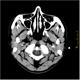

In [4]:
# C:\Users\jeff1\OneDrive\Escritorio\IA-2022_1\datos_cerebros\paciente 1\1\
img = Image.open('./datos_cerebros/paciente 1/1/Paciente1CC-27-10-1988- CT from 18-01-2011 S0 I1.BMP')
img = img.resize((80, 80))
display(img)

In [5]:
mat = np.asarray(img)
print(mat.shape)
# print(mat[0].shape)
print(mat[0][0])

(80, 80, 3)
[64 62 56]


In [6]:
# https://www.geeksforgeeks.org/calculate-the-euclidean-distance-using-numpy/
def euclidean(x1, x2):
    return distance.euclidean(x1, x2)

def chebychev(x1, x2):
    return distance.chebyshev(x1, x2)

def manhattan(x1, x2):
    return distance.cityblock(x1, x2)

In [7]:
# https://neptune.ai/blog/k-means-clustering
def rand_centroids(data, k, distance):
    r, c = data.shape
    c_idx = np.random.choice(r, k)
    return data.iloc[c_idx].to_numpy()

def plus_plus(data, k, distance):
    centroids = [ data.sample(n=1).to_numpy().tolist()[0] ]
    for _ in range(k-1):
        new_c = ([],-1)         # centroid, distance to c
        for i in range(len(data)):
            x_i = data.iloc[i].to_numpy().tolist()
            if x_i not in centroids:
                d = 0
                for c in centroids:
                    d += pow(distance(c, x_i), 2)
                d /= len(centroids)
                new_c = (x_i, d) if new_c[1] < d else new_c
        centroids.append(new_c[0])
    return np.matrix(centroids)    

In [8]:
x, y, z = mat.shape

In [9]:
pixels = [list(mat[i][j]) + [i, j] for i in range(len(mat)) for j in range(len(mat[i])) ]
pixels = pd.DataFrame(pixels, columns=['R', 'G', 'B', 'i', 'j'])
pixels

,R,G,B,i,j
0,64,62,56,0,0
1,36,35,32,0,1
2,36,35,32,0,2
3,36,35,32,0,3
4,36,35,32,0,4
...,...,...,...,...,...
6395,103,102,97,79,75
6396,103,102,97,79,76
6397,103,102,97,79,77
6398,103,102,97,79,78


In [41]:
class K_Means():
    def __init__(self, n, distance=euclidean, cc=rand_centroids):
        self.data = None
        self.n = n          # n° centroids
        self.K = None
        self.d = distance
        self.cc = cc        # centroid criteria

    def new_centroids(self, idx):
        new_K = [[] for _ in self.K]

        for i in range(len(self.K)):
            # obtener indices de todos los elementos pertenecientes al cluster i de la lista de indeices
            idx_curr_cluster = idx[idx['cluster'] == i]['idx'].to_list()
            # obtener elementos correspondientes al cluster i
            cluster_i_data = self.data.loc[idx_curr_cluster]
            
            if cluster_i_data.empty:
                new_K[i] = self.K[i]
            else:
                new_K[i] = self.data.loc[idx_curr_cluster].mean().to_numpy()
            
        return np.array(new_K, dtype=object)

    def label(self):
        """
        for each row of DataFrame 
            generate 3-tuple for each cluster
                [(row_id, cluster_i, distance), ...]
            get 2-tuple with the minimun distance
                (row_id, cluster_i)
        trasform list [(row_id, cluster_i), ...] to DataFrame and return it
        """
        idx = [
                min([(idx, i, self.d(self.K[i], self.data.iloc[idx].to_numpy())) for i in range(len(self.K))], key=itemgetter(2))[:-1] 
                for idx in range(len(self.data))
            ]
        return pd.DataFrame(idx, columns=['idx', 'cluster'])  

    def execute(self, d):
        self.data = d
        new_K = self.cc(self.data, self.n, self.d)

        i = 0
        idx = None
        while not (self.K == new_K).all():
            self.K = new_K
            idx = self.label()
            new_K = self.new_centroids(idx)
            print(new_K)
            time.sleep(5)
            i += 1
        print(f'\titerations {i}')
        return new_K, idx

In [42]:
K = 5
data = pixels.copy()
data.loc[:, ['R', 'G', 'B']]

,R,G,B
0,64,62,56
1,36,35,32
2,36,35,32
3,36,35,32
4,36,35,32
...,...,...,...
6395,103,102,97
6396,103,102,97
6397,103,102,97
6398,103,102,97


In [43]:
k = K_Means(K, cc=plus_plus)

In [44]:
# kernels, clusters = k.execute(data)
# clusters.to_csv('./clusters_idx.csv')

[[15.819232275754015 15.76478652565609 15.327653740697219
  38.51449275362319 39.808656482569525]
 [-68.60714285714286 -68.60714285714286 -68.60714285714286
  11.392857142857142 36.0]
 [115.52212389380531 115.20353982300885 113.59292035398231
  53.796460176991154 59.08849557522124]
 [-92.27504553734062 -92.27595628415301 -92.28233151183971
  42.73952641165756 36.82331511839708]
 [122.85454545454546 122.83636363636364 122.72727272727273
  51.25454545454546 25.818181818181817]]
[[5.523549934583515 5.489315307457479 5.147405146096816 37.77474923680767
  39.70693414740514]
 [-54.447916666666664 -54.447916666666664 -54.447916666666664
  31.526041666666668 34.84375]
 [95.25904761904762 95.01142857142857 93.65523809523809 46.12952380952381
  49.69904761904762]
 [-104.14642451759364 -104.14755959137344 -104.15550510783201
  44.74460839954597 37.130533484676505]
 [112.08333333333333 111.95370370370371 111.30555555555556
  45.71296296296296 24.12037037037037]]
[[3.9700652712131443 3.935178933153

In [10]:
clusters = pd.read_csv('./clusters_idx.csv')
pixels['clusters'] = clusters['cluster']
pixels.head()

,R,G,B,i,j,clusters
0,64,62,56,0,0,2
1,36,35,32,0,1,2
2,36,35,32,0,2,2
3,36,35,32,0,3,2
4,36,35,32,0,4,2


In [11]:
colors = ['r', 'g', 'b', 'y', 'b']

In [12]:
m = np.zeros((100, 100)).astype(int)
for _ in range(len(pixels)):
    row = pixels.iloc[_]
    m[row['i'], row['j']] = row['clusters']
m


array([[2, 2, 2, ..., 0, 0, 0],
       [2, 0, 0, ..., 0, 0, 0],
       [2, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

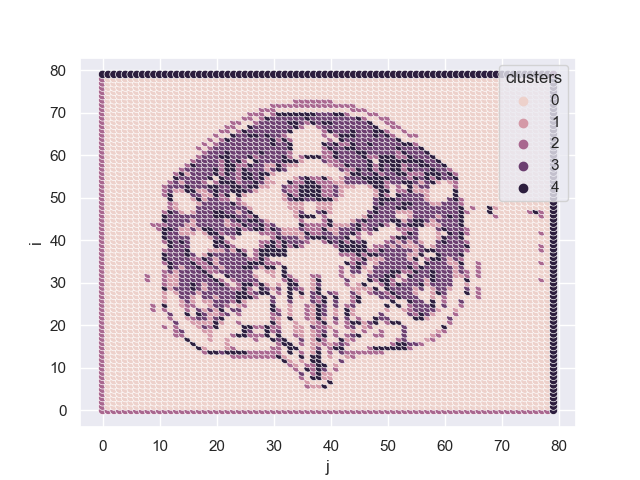

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

sns.set(style = "darkgrid")

fig = plt.figure()
ax = fig.add_subplot()

x = pixels['i']
y = pixels['j']

# pixels[pixels['clusters'] == 1]
sns.scatterplot(data=pixels, x='j', y='i', hue='clusters')

plt.show()

In [14]:
pixels[pixels['clusters'] == 2]
pixels['k'] = 1
pixels.head()

,R,G,B,i,j,clusters,k
0,64,62,56,0,0,2,1
1,36,35,32,0,1,2,1
2,36,35,32,0,2,2,1
3,36,35,32,0,3,2,1
4,36,35,32,0,4,2,1


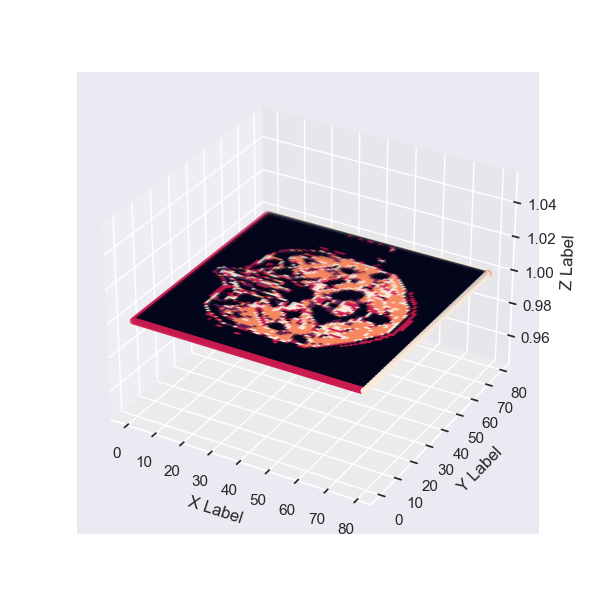

In [15]:
fig = plt.figure(figsize=(6,6))

plt.clf()
ax = fig.add_subplot(111, projection='3d') # Method 2

x = pixels['i']
y = pixels['j']
z = pixels['k']

ax.scatter(x, y, z, c=pixels['clusters'], marker='o')
ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')
plt.show()

- [K-means clustering](https://neptune.ai/blog/k-means-clustering)
- [Clustering algorithms](https://neptune.ai/blog/clustering-algorithms)
- [Clustering algorithms](https://neptune.ai/blog/clustering-algorithms#density)
- [Centroid initialization](https://www.kdnuggets.com/2020/06/centroid-initialization-k-means-clustering.html)
- [Optimum epsilon](http://www.sefidian.com/2020/12/18/how-to-determine-epsilon-and-minpts-parameters-of-dbscan-clustering/)